In [ ]:
#load packages
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [9]:
# extract data from the API
url = "https://opendataapi.dmi.dk/v2/metObs/collections/observation/items"

params = {
    "stationId": "06180",        # Copenhagen
    "parameterId": "temp_dry",   # Dry bulb temperature
    "datetime": "2024-01-01T00:00:00Z/2024-01-31T23:59:59Z",
    "limit": 10000
}

response = requests.get(url, params=params)
data = response.json()

print(data["features"][0])

{'type': 'Feature', 'id': '2a0d15bc-1ce5-5fbf-8c0c-6c0415593234', 'geometry': {'type': 'Point', 'coordinates': [12.6455, 55.614]}, 'properties': {'parameterId': 'temp_dry', 'created': '2025-08-04T16:34:02.651425Z', 'value': 4.5, 'observed': '2024-01-31T23:50:00Z', 'stationId': '06180'}}


In [10]:
# Extract the properties from each feature
records = [feature["properties"] for feature in data["features"]]

# Convert to DataFrame
df = pd.DataFrame(records)

# Convert the observed column to datetime
df["observed"] = pd.to_datetime(df["observed"])

# Sort by time
df = df.sort_values("observed").reset_index(drop=True)

print(df.shape)
df.head()

(4464, 5)


,parameterId,created,value,observed,stationId
0,temp_dry,2025-08-04T17:02:09.426815Z,5.4,2024-01-01 00:00:00+00:00,06180
1,temp_dry,2025-08-04T17:02:09.438916Z,5.5,2024-01-01 00:10:00+00:00,06180
2,temp_dry,2025-08-04T17:02:09.4529Z,5.5,2024-01-01 00:20:00+00:00,06180
3,temp_dry,2025-08-04T17:02:09.46698Z,5.4,2024-01-01 00:30:00+00:00,06180
4,temp_dry,2025-08-04T17:02:09.48085Z,5.4,2024-01-01 00:40:00+00:00,06180


- <b>value</b> - temp in °C
- <b>observed</b> - timestamps each 10 min
- <b>created</b> - DMI processed the reading (not gonna use this)
- <b>parameterID</b> & <b>stationID</b> (same for every row - not gonna use this)

In [11]:
#sort out the relevant data
df = df[["observed", "value"]].rename(columns={"value": "temp_C"})
df.head()

,observed,temp_C
0,2024-01-01 00:00:00+00:00,5.4
1,2024-01-01 00:10:00+00:00,5.5
2,2024-01-01 00:20:00+00:00,5.5
3,2024-01-01 00:30:00+00:00,5.4
4,2024-01-01 00:40:00+00:00,5.4


In [12]:
#set date + time as index
df = df.set_index("observed")
df.head()

,temp_C
observed,
2024-01-01 00:00:00+00:00,5.4
2024-01-01 00:10:00+00:00,5.5
2024-01-01 00:20:00+00:00,5.5
2024-01-01 00:30:00+00:00,5.4
2024-01-01 00:40:00+00:00,5.4


### analysis
we just demonstrated that the data was succesfully extruded from the open API. next step is to make som dataanalysis. 
1) daily averages
2) visualization

In [14]:
daily = df.resample("D").agg({"temp_C": ["mean", "max", "min"]})

# Flatten the column names
daily.columns = ["temp_mean", "temp_max", "temp_min"]

daily = daily.round(1)

daily.head()

,temp_mean,temp_max,temp_min
observed,,,
2024-01-01 00:00:00+00:00,5.2,5.8,3.7
2024-01-02 00:00:00+00:00,2.7,4.1,1.6
2024-01-03 00:00:00+00:00,1.1,1.8,-0.2
2024-01-04 00:00:00+00:00,-3.3,0.0,-7.2
2024-01-05 00:00:00+00:00,-6.9,-4.6,-8.6


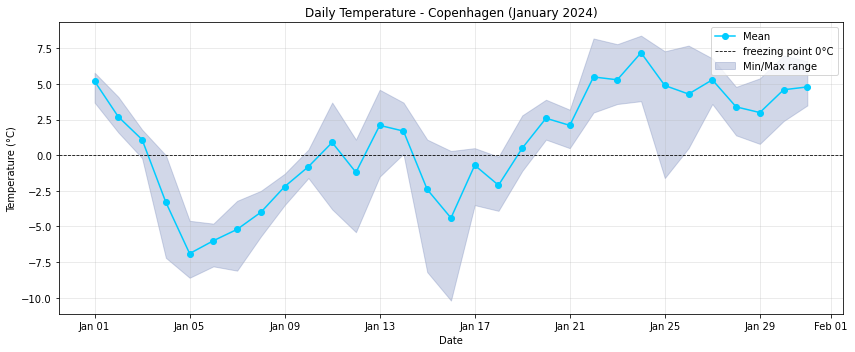

In [ ]:
# plot the data
fig, ax = plt.subplots(figsize=(12, 5))

#adjust x-axis labels
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

ax.plot(daily.index, daily["temp_mean"], label="Mean", color="#00ccff", marker="o")
ax.fill_between(daily.index, daily["temp_min"], daily["temp_max"], 
                alpha=0.3, color="#697db4", label="Min/Max range")

ax.axhline(0, color="#000000", linestyle="--", linewidth=0.8, label="freezing point 0°C")


ax.set_title("Daily Temperature - Copenhagen (January 2024)")
ax.set_xlabel("Date")
ax.set_ylabel("Temperature (°C)")

ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

It was really cold on the 16th of January 2024 in Copenhagen — the average temperature was below freezing, and the minimum dropped to –10 °C. If the weather had stayed like that, the city would probably have announced that it was safe to walk on the lakes.

But no. Because the temperature kept changing, the 24th of January ended up being the warmest day of the whole month, almost reaching 7.5 °C. If there was any ice left on the lakes at that point, you would definitely have fallen straight through.

Stay safe out there.